In [61]:
import glob
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.interpolate import griddata, RegularGridInterpolator
from scipy.stats import chi2 as chi2_dist

In [ ]:
CI = 0.997
SIM_ROOT = '../SinglePBH'
MPBH = 5e14 # [g]
G_CGS = 6.674e-8
OBS_CSV = '../data/MWDD-export.csv'
resolution = 200
MSOLAR = 1.989e33 # [g]
FREE_PARAM = 2 # MPBH and rho

In [ ]:
dir_re = re.compile(r"PBH_M([\d.eE+-]+)_N([\d.eE+-]+)")
file_re = re.compile(r"rho0([\d.eE+-]+)\.csv$")

pattern = os.path.join(SIM_ROOT, f"PBH_M{MPBH:.1e}_N*", "rho0*.csv")
paths = sorted(glob.glob(pattern))

records = []

for path in paths:
	dirname = os.path.basename(os.path.dirname(path))
	filename = os.path.basename(path)
	
	dir_match = dir_re.search(dirname)
	file_match = file_re.search(filename)
	
	if not dir_match or not file_match:
		continue

	N = float(dir_match.group(2))
	rho = float(file_match.group(1))
	df = pd.read_csv(path)

	surface = df.loc[df["radius"].idxmax()]
	records.append((N, df['mass'], surface["temperature"], surface["mass"], surface["radius"]))

sim_df = pd.DataFrame(records, columns=["N", "rho", "T_surface", "M_surface", "R_surface"])
N_values = np.sort(sim_df["N"].unique())
rho_values = np.sort(sim_df["rho"].unique())

In [ ]:
def build_grid(column):
	grid = np.full((len(rho_values), len(N_values)), np.nan)
	for _, row in sim_df.iterrows():
		i = np.searchsorted(rho_values, row["rho"])
		j = np.searchsorted(N_values, row["N"])
		grid[i, j] = row[column]

    # interpolation
	nan_mask = np.isnan(grid)
	if nan_mask.any():
		ii, jj = np.meshgrid(np.arange(len(rho_values)), np.arange(len(N_values)), indexing="ij")
		valid = ~nan_mask
		grid[nan_mask] = griddata(
			points=np.column_stack([ii[valid], jj[valid]]),
			values=grid[valid],
			xi=np.column_stack([ii[nan_mask], jj[nan_mask]]),
			method="nearest",
		)
	return grid

log_rho_vals = np.log10(rho_values)
log_N_vals = np.log10(N_values)
N_fine = np.logspace(log_N_vals.min(), log_N_vals.max(), resolution)
rho_fine = np.logspace(log_rho_vals.min(), log_rho_vals.max(), resolution)
rho_fine_grid, N_fine_grid = np.meshgrid(rho_fine, N_fine, indexing="ij")  # was meshgridding against 'resolution' (an int), not N_fine

In [65]:
def interpolate_fine(grid):
	log_rho = np.log10(rho_values)
	log_N = np.log10(N_values)
	interp = RegularGridInterpolator((log_rho, log_N), grid, method="cubic", bounds_error=False, fill_value=None)
	query_points = np.column_stack([np.log10(rho_fine_grid).ravel(), np.log10(N_fine_grid).ravel()])
	return interp(query_points).reshape(rho_fine_grid.shape)

In [66]:
T_fine = 10.**interpolate_fine(np.log10(build_grid("T_surface")))
M_fine = interpolate_fine(build_grid("M_surface"))       # already O(1) in solar masses, no log needed
R_fine = 10.**interpolate_fine(np.log10(build_grid("R_surface")))

obs = pd.read_csv(OBS_CSV)
obs_valid = obs.dropna(subset=["teff", "mass", 'Dteff', 'Dmass', 'logg', 'Dlogg'], how="all").copy()

# R = sqrt(G*M/g) [cm]
g_cgs = 10.**obs_valid["logg"]
M_g = obs_valid["mass"] * MSOLAR
R_cm = np.sqrt(G_CGS * M_g / g_cgs)
obs_valid["radius_km"] = R_cm / 1e5

# propagate sigma_R via d(lnR) = 0.5*d(lnM) - 0.5*ln(10)*d(logg)
sigma_lnM = obs_valid["Dmass"] / obs_valid["mass"]
sigma_lng = np.log(10.) * obs_valid["Dlogg"]
sigma_lnR = 0.5 * np.sqrt(sigma_lnM**2 + sigma_lng**2)
obs_valid["sigma_radius_km"] = obs_valid["radius_km"] * sigma_lnR

/Users/caritsang/miniforge3/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [69]:
results = []
for _, star in obs_valid.iterrows():
	chi2_map = (star["teff"] - T_fine)**2 / star["Dteff"]**2 + (star["mass"] - M_fine)**2 / star["Dmass"]**2 + (star["radius_km"] - R_fine)**2 / star["sigma_radius_km"]**2
	n_terms = 3
	
	dof = n_terms - FREE_PARAM
	i_best, j_best = np.unravel_index(np.argmin(chi2_map), chi2_map.shape)
	chi2_best = chi2_map[i_best, j_best]

	# dof <= 0 means there isn't enough independent data to constrain this star at all;
	# chi2_dist.ppf/cdf return nan for dof <= 0, which silently evaluates good_fit=False
	# via 'nan < x' -- guarding explicitly here instead so it's clear WHY it was excluded
	if dof > 0:
		chi2_cut = chi2_dist.ppf(CI, dof)
		p_value = 1. - chi2_dist.cdf(chi2_best, dof)
		good_fit = chi2_best < chi2_cut
	else:
		chi2_cut = np.nan
		p_value = np.nan
		good_fit = False

	results.append({
		"wdid": star["wdid"], "n_terms": n_terms, "dof": dof,
		"N_best": N_fine[j_best], "rho_best": rho_fine[i_best],
		"chi2_best": chi2_best, "chi2_cut": chi2_cut, "p_value": p_value,
		"good_fit": good_fit,
	})

fit_df = pd.DataFrame(results)
print(f"\nFit results (confidence level = {CI:.1%}):")
good_fits = fit_df[fit_df["good_fit"]]

/var/folders/f5/93qk9czs7835g6z9_k6k6wvc0000gn/T/ipykernel_14294/1469375513.py:3: RuntimeWarning: divide by zero encountered in divide
  chi2_map = (star["teff"] - T_fine)**2 / star["Dteff"]**2 + (star["mass"] - M_fine)**2 / star["Dmass"]**2 + (star["radius_km"] - R_fine)**2 / star["sigma_radius_km"]**2



Fit results (confidence level = 99.7%):


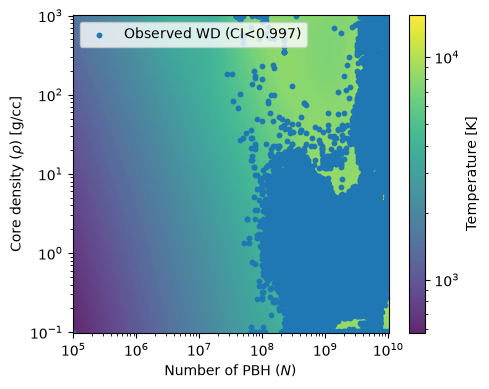

In [79]:
fig, ax = plt.subplots(figsize=(5,4))

T_grid_raw = build_grid("T_surface")
valid = T_grid_raw[~np.isnan(T_grid_raw)]
norm = LogNorm(vmin=valid.min(), vmax=valid.max()) if valid.size and valid.min() > 0 else None

mesh = ax.pcolormesh(N_fine, rho_fine, T_fine, shading="auto", norm=norm, alpha=0.85)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Number of PBH ($N$)")
ax.set_ylabel(r"Core density ($\rho$) [g/cc]")

cbar = fig.colorbar(mesh, ax=ax)
cbar.set_label("Temperature [K]")

ax.scatter(good_fits["N_best"], good_fits["rho_best"], s=10, label=r"Observed WD (CI<0.997)")
ax.legend()

plt.tight_layout()